<a href="https://colab.research.google.com/github/MadhujhaMj/Trade_Sentiment_Analysis/blob/main/Fear_greed_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [77]:
df=pd.read_csv('/content/fear_greed_index.csv')

In [78]:
df.head(3)

,timestamp,value,classification,date
0,1517463000,30,Fear,01/02/2018
1,1517549400,15,Extreme Fear,02/02/2018
2,1517635800,40,Fear,03/02/2018


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [86]:
db = pd.read_csv('/content/historical_data.csv')

In [87]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [88]:
db.describe()

,Execution Price,Size Tokens,Size USD,Start Position,Closed PnL,Order ID,Fee,Trade ID,Timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,2.112240e+05
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,1.737744e+12
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,8.689920e+09
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,1.680000e+12
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,1.740000e+12
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,1.740000e+12
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,1.740000e+12
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,1.750000e+12


In [89]:
db['datetime'] = pd.to_datetime(data['Timestamp'], unit='ms')
db['date'] = db['datetime'].dt.date

In [90]:
db.head(1)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27


In [91]:
df['date'] = pd.to_datetime(df['date'], format='%d/%m/%Y')
df['date'] = df['date'].dt.date

In [92]:
df.head(1)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01


In [93]:
df1= db.merge(df[['date','classification']], on='date', how='left')

In [94]:
df1.head(5)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed


In [95]:
df1['is_win'] = df1['Closed PnL'] > 0 ##This will true or False

In [96]:
df1.head(1)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,datetime,date,classification,is_win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.0,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False


In [125]:
##To Reduce 4 Categories to 2 categories
def simplify_sentiment(x):
    # Convert x to string to handle cases where it might be a float (e.g., NaN)
    if 'Fear' in str(x):
        return 'Fear'
    else:
        return 'Greed'

df1['sentiment'] = df1['classification'].apply(simplify_sentiment)

In [129]:
df1.groupby('sentiment')['Closed PnL'].mean() ##Grouping by sentiment and calculating the Closed PnL mean


,Closed PnL
sentiment,
Fear,50.047622
Greed,46.501542


In [130]:
df1.groupby('sentiment')['is_win'].mean() ##Grouping by sentiment and calculating the is_win mean

,is_win
sentiment,
Fear,0.415146
Greed,0.404548


In [99]:
df1.groupby('sentiment').agg({
    'Size Tokens':'mean',          ## Size of traded quantity group by sentiment
    'Account':'count'              ##Toal no. of trades group by sentiment by counting account
})

,Size Tokens,Account
sentiment,,
Fear,3071.523165,133871
Greed,7309.060626,77353


In [100]:
median_size = df1['Size Tokens'].median()

In [101]:
df1['size_segment'] = df1['Size Tokens'].apply(
    lambda x: 'Large' if x > median_size else 'Small'
)

In [102]:
df1.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,datetime,date,classification,is_win,sentiment,size_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False,Greed,Large
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False,Greed,Small
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False,Greed,Large


In [103]:
df1['size_segment'] = df1['Size Tokens'] > median_size
df1['size_segment'] = df1['size_segment'].map({True: 'Large', False: 'Small'})

In [104]:
df1['Size Tokens'] = pd.to_numeric(df1['Size Tokens'], errors='coerce')

In [105]:
df1.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Crossed,Fee,Trade ID,Timestamp,datetime,date,classification,is_win,sentiment,size_segment
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,True,0.345404,8.950000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False,Greed,Large
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,True,0.005600,4.430000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False,Greed,Small
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,True,0.050431,6.600000e+14,1.730000e+12,2024-10-27 03:33:20,2024-10-27,Greed,False,Greed,Large


In [106]:
df1.groupby('sentiment')['Closed PnL'].agg(['mean','sum','count'])

,mean,sum,count
sentiment,,,
Fear,50.047622,6.699925e+06,133871
Greed,46.501542,3.597034e+06,77353


In [108]:
df1.groupby('sentiment')['Size Tokens'].mean()

,Size Tokens
sentiment,
Fear,3071.523165
Greed,7309.060626


In [109]:
df1.groupby(['sentiment','size_segment'])['Closed PnL'].mean()

sentiment  size_segment
Fear       Large           78.496957
           Small           19.644162
Greed      Large           79.682937
           Small           17.163317
Name: Closed PnL, dtype: float64

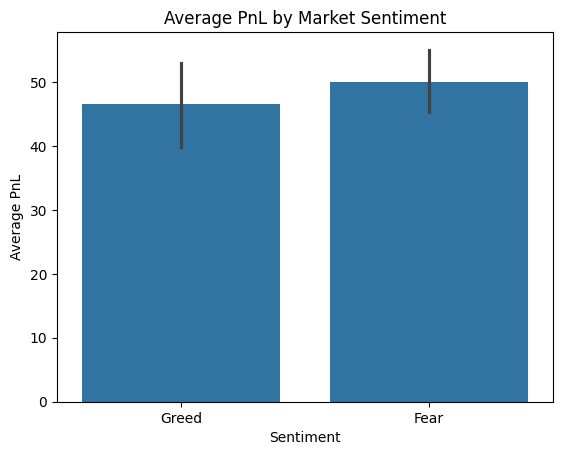

In [110]:
sns.barplot(x='sentiment', y='Closed PnL', data=df1, estimator='mean')
plt.title('Average PnL by Market Sentiment')
plt.ylabel('Average PnL')
plt.xlabel('Sentiment')
plt.show()

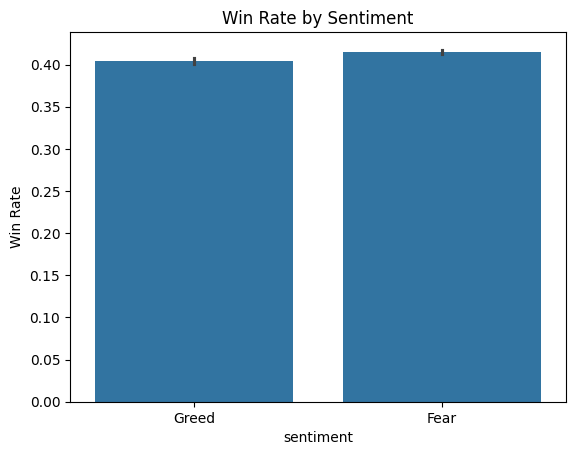

In [111]:
sns.barplot(x='sentiment', y='is_win', data=df1)
plt.title('Win Rate by Sentiment')
plt.ylabel('Win Rate')
plt.show()

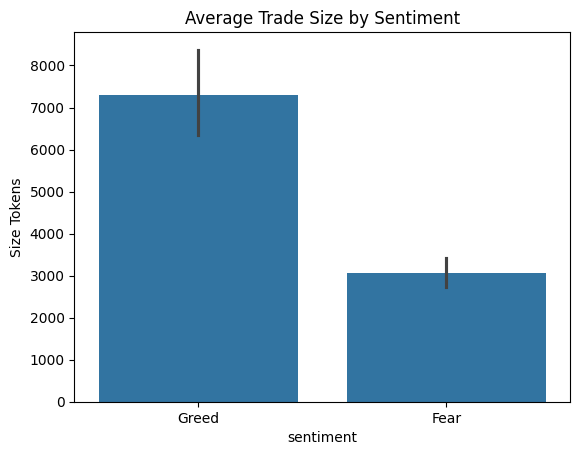

In [112]:
sns.barplot(x='sentiment', y='Size Tokens', data=df1, estimator='mean')
plt.title('Average Trade Size by Sentiment')
plt.show()

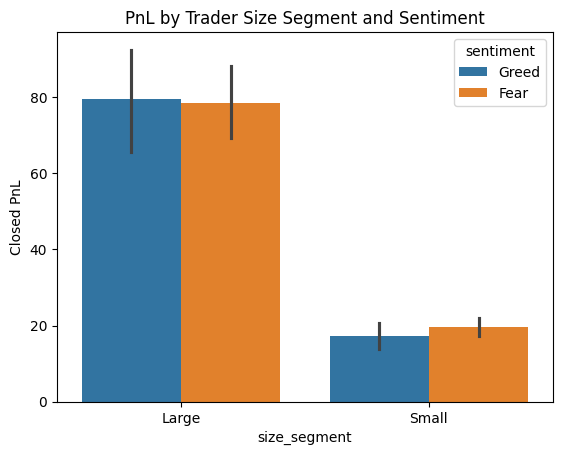

In [113]:
sns.barplot(x='size_segment', y='Closed PnL', hue='sentiment', data=df1)
plt.title('PnL by Trader Size Segment and Sentiment')
plt.show()

In [114]:
df1['sentiment_num'] = df1['sentiment'].map({'Fear': 0, 'Greed': 1})

In [115]:
features = ['Size Tokens', 'sentiment_num']

In [116]:
y = df1['is_win'].astype(int)
X = df1[features]

In [118]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [119]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=50, max_depth=5)
model.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, n_estimators=50)

In [121]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy_score(y_test, y_pred)

0.5912178956089478

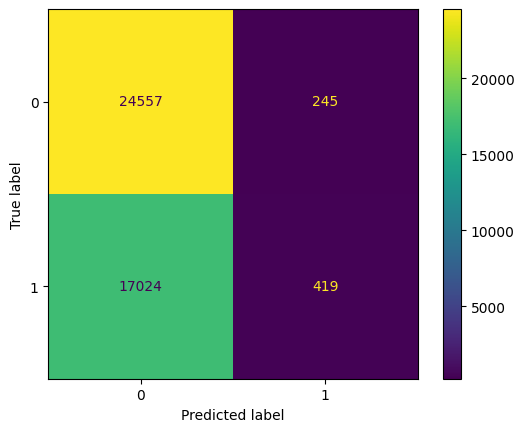

In [122]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [131]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators':[50,100],
    'max_depth':[5,10],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(model, params, scoring='recall', cv=3)
grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=RandomForestClassifier(max_depth=5, n_estimators=50),
             param_grid={'max_depth': [5, 10], 'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]},
             scoring='recall')

In [132]:
grid.best_params_

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

In [136]:
best_grid = grid.best_estimator_
y_pred_grid = best_grid.predict(X_test)
grid_accuracy = accuracy_score(y_test, y_pred_grid)

In [137]:
grid_accuracy

0.6029352586104865

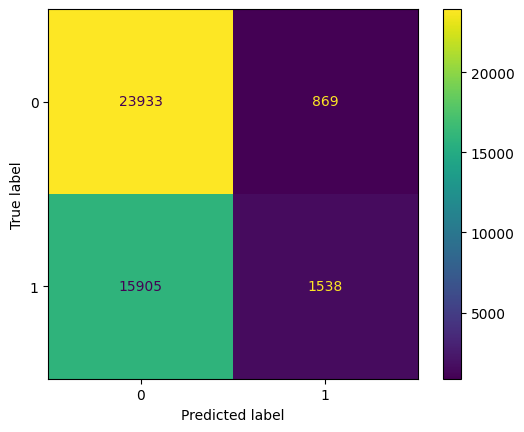

In [138]:
cm = confusion_matrix(y_test, y_pred_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()



1. Insights 1 - Traders achieve higher average PnL during Fear (50.0) compared to Greed (46.5), despite market uncertainty
2. Win rate is slightly higher during Fear (41.5%) vs Greed (40.4%)
3. Average trade size during Greed (7309) is more than 2X higher thanduring Fear(3071).







*   Strategy 1 - Increase trading activity during Fear periods, as both PnL and win rate are higher, indicating more exploitable opportunities.
*   Strategy 2 - Reduce position sizes during Greed periods, as traders tend to over-leverage and achieve lower returns despite higher exposure.
*   Strategy 3 - Small traders should avoid aggressive trading during Greed phases, while large traders can maintain performance due to better capital and risk management

